In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [269]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [270]:
methods = ['demultiplex', 'demultiplex2', 'htodemux', 'hashsolo', 'hasheddrops',
           'bffraw', 'bffcluster', 'gmmdemux', 'demuxmix', 'demuxmixnaive', 'demuxtags', 'beacon']

datasets = [
    'mcginnis_ms',
    'mcginnis_ab',
    'bar11',
    'gaublomme',
    'howitt_batch1_c1',
    'howitt_batch1_c2',
    'howitt_batch2_c1',
    'howitt_batch2_c2',
    'howitt_batch3_c1',
    'howitt_batch3_c2',
    'howitt_capture1',
    'howitt_capture2',
    'howitt_capture3',
    'cook_mix1',
    'cook_mix2',
    'cook_mix3a',
    'cook_mix3b',
    'cook_mix4a',
    'cook_mix4b',
]

#notes for methods that did not run
notes = {
    ('cook_mix4a', 'demultiplex2'): 'Error',
    ('cook_mix1', 'demuxmix'): 'No RNA',
    ('cook_mix2', 'demuxmix'): 'No RNA',
    ('cook_mix3a', 'demuxmix'): 'No RNA',
    ('cook_mix3b', 'demuxmix'): 'No RNA',
    ('cook_mix4a', 'demuxmix'): 'No RNA',
    ('cook_mix4b', 'demuxmix'): 'No RNA',
    ('howitt_batch1_c1', 'demuxmix'): 'No RNA',
    ('howitt_batch1_c2', 'demuxmix'): 'No RNA',
    ('howitt_batch2_c1', 'demuxmix'): 'No RNA',
    ('howitt_batch2_c2', 'demuxmix'): 'No RNA',
    ('howitt_batch3_c1', 'demuxmix'): 'No RNA',
    ('howitt_batch3_c2', 'demuxmix'): 'No RNA',
    ('howitt_capture1', 'demuxmix'): 'No RNA',
    ('howitt_capture2', 'demuxmix'): 'No RNA',
    ('howitt_capture3', 'demuxmix'): 'No RNA',
    ('cook_mix1', 'demuxmixnaive'): 'Error',
    ('cook_mix2', 'demuxmixnaive'): 'Error',
    ('cook_mix3a', 'demuxmixnaive'): 'Error',
    ('cook_mix3b', 'demuxmixnaive'): 'Error',
    ('cook_mix4a', 'demuxmixnaive'): 'Error',
    ('cook_mix4b', 'demuxmixnaive'): 'Error',
    ('cook_mix1', 'gmmdemux'): 'DNF',
    ('cook_mix2', 'gmmdemux'): 'DNF',
    ('cook_mix3a', 'gmmdemux'): 'DNF',
    ('cook_mix3b', 'gmmdemux'): 'DNF',
    ('cook_mix4a', 'gmmdemux'): 'DNF',
    ('cook_mix4b', 'gmmdemux'): 'DNF',
    ('cook_mix1', 'htodemux'): 'Error',
    ('cook_mix2', 'htodemux'): 'Error',
    ('cook_mix3a', 'htodemux'): 'Error',
    ('cook_mix3b', 'htodemux'): 'Error',
    ('cook_mix4a', 'htodemux'): 'Error',
    ('cook_mix4b', 'htodemux'): 'Error',
}


In [271]:
#load runtimes
runtime_files = glob.glob('results/*/*/runtime.csv')

all_runtimes = []
for f in runtime_files:
    df = pd.read_csv(f)
    all_runtimes.append(df)

runtimes_df = pd.concat(all_runtimes, ignore_index=True)
runtimes_df = runtimes_df[runtimes_df['dataset'].isin(datasets)]

print(f'Total runtime records: {len(runtimes_df)}')
runtimes_df

Total runtime records: 213


,dataset,method,runtime_seconds
0,bar11,hasheddrops,0.178
1,howitt_batch3_c2,hasheddrops,0.189
2,howitt_batch2_c2,hasheddrops,0.170
3,cook_mix3a,hasheddrops,0.711
4,howitt_batch1_c1,hasheddrops,0.160
...,...,...,...
208,howitt_capture2,beacon,29.860
209,howitt_batch1_c2,beacon,21.798
210,howitt_capture3,beacon,28.142
211,cook_mix4b,beacon,141.559


In [272]:
#add notes for NaNs
notes_rows = []
for (dataset, method), note in notes.items():
    notes_rows.append({
        'dataset': dataset,
        'method': method,
        'runtime_seconds': float('nan'),
        'note': note
    })

notes_df = pd.DataFrame(notes_rows)

# add note column to runtimes_df
runtimes_df['note'] = ''

# combine
runtimes_df = pd.concat([runtimes_df, notes_df], ignore_index=True)
runtimes_df = runtimes_df[runtimes_df['dataset'].isin(datasets)]
runtimes_df.to_csv('analysis/time_analysis/runtimes_by_method.csv', index=False)

print(f'Total runtime records: {len(runtimes_df)}')
runtimes_df

Total runtime records: 247


,dataset,method,runtime_seconds,note
0,bar11,hasheddrops,0.178,
1,howitt_batch3_c2,hasheddrops,0.189,
2,howitt_batch2_c2,hasheddrops,0.170,
3,cook_mix3a,hasheddrops,0.711,
4,howitt_batch1_c1,hasheddrops,0.160,
...,...,...,...,...
242,cook_mix2,htodemux,NaN,Error
243,cook_mix3a,htodemux,NaN,Error
244,cook_mix3b,htodemux,NaN,Error
245,cook_mix4a,htodemux,NaN,Error


In [273]:
#summary stats by method
method_stats = runtimes_df.groupby('method')['runtime_seconds'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2).reset_index()
method_stats.columns = ['method', 'mean', 'median', 'std', 'min', 'max']
method_stats = method_stats.sort_values('mean')
print('Runtime summary by method (seconds):')

method_stats

Runtime summary by method (seconds):


,method,mean,median,std,min,max
10,hasheddrops,0.35,0.17,0.30,0.13,0.83
7,demuxmixnaive,0.97,0.88,0.63,0.21,2.18
12,htodemux,1.20,1.10,0.72,0.30,2.38
9,gmmdemux,2.01,2.04,0.25,1.73,2.45
11,hashsolo,2.74,0.14,4.05,0.02,9.56
6,demuxmix,12.53,13.32,5.19,6.13,17.34
4,demultiplex,33.86,19.50,32.28,2.15,96.90
1,bff_cluster,49.59,37.24,45.71,12.61,158.01
2,bff_raw,49.59,37.24,45.71,12.61,158.01
0,beacon,52.74,44.40,40.30,4.29,141.56


In [274]:
#summary stats by dataset
dataset_stats = runtimes_df.groupby('dataset')['runtime_seconds'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2).reset_index()
dataset_stats.columns = ['dataset', 'mean', 'median', 'std', 'min', 'max']
dataset_stats = dataset_stats.sort_values('mean')
print('Runtime summary by dataset (seconds):')
dataset_stats

Runtime summary by dataset (seconds):


,dataset,mean,median,std,min,max
7,gaublomme,5.89,2.15,7.50,0.03,25.56
18,mcginnis_ms,8.49,6.11,9.27,0.04,31.41
17,mcginnis_ab,9.84,7.98,9.45,0.04,31.06
16,howitt_capture3,12.70,12.23,12.89,0.02,38.48
15,howitt_capture2,12.75,8.58,14.44,0.03,44.96
0,bar11,13.78,8.00,19.82,0.08,74.53
14,howitt_capture1,14.40,8.80,16.72,0.02,51.19
8,howitt_batch1_c1,15.48,15.04,15.40,0.08,44.66
9,howitt_batch1_c2,16.66,16.71,16.69,0.09,48.29
10,howitt_batch2_c1,33.56,25.32,51.37,0.14,186.38


In [275]:
pivot = runtimes_df.pivot_table(
    index='method',
    columns='dataset',
    values='runtime_seconds'
).round(2)

pivot

dataset,bar11,cook_mix1,cook_mix2,cook_mix3a,cook_mix3b,cook_mix4a,cook_mix4b,gaublomme,howitt_batch1_c1,howitt_batch1_c2,howitt_batch2_c1,howitt_batch2_c2,howitt_batch3_c1,howitt_batch3_c2,howitt_capture1,howitt_capture2,howitt_capture3,mcginnis_ab,mcginnis_ms
method,,,,,,,,,,,,,,,,,,,
beacon,14.18,108.91,104.85,81.43,87.71,92.88,141.56,4.29,18.92,21.80,44.40,46.71,66.59,58.62,37.05,29.86,28.14,7.98,6.11
bff_cluster,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
bff_raw,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
cmddemux,6.45,3304.91,1739.50,2478.08,1717.57,2745.65,3616.56,1.41,37.45,40.99,186.38,336.45,580.84,264.75,51.19,44.96,38.48,13.12,7.40
demultiplex,8.00,93.56,96.90,55.61,38.52,43.18,42.65,2.15,11.16,11.63,19.50,48.98,95.53,39.77,5.00,5.88,13.30,7.36,4.57
demultiplex2,17.28,142.44,136.40,148.09,137.90,NaN,145.19,9.45,24.05,25.70,41.22,42.78,51.65,51.04,27.37,25.47,25.68,16.73,16.86
demuxmix,16.10,NaN,NaN,NaN,NaN,NaN,NaN,6.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.34,10.55
demuxmixnaive,0.52,NaN,NaN,NaN,NaN,NaN,NaN,0.21,1.00,1.03,1.26,1.53,2.18,2.05,0.88,0.61,0.42,0.57,0.34
demuxtags,74.53,28348.53,22653.17,19049.44,22657.53,25787.26,22501.39,25.56,44.66,48.29,31.14,52.06,29.39,82.76,12.60,11.28,11.16,31.06,31.41


In [276]:
annot_matrix = pd.DataFrame('', index=pivot.index, columns=pivot.columns)

for col in pivot.columns:
    for idx in pivot.index:
        val = pivot.loc[idx, col]
        if pd.isna(val):
            # check if there's a note
            note_key = (col, idx)
            if note_key in notes:
                annot_matrix.loc[idx, col] = notes[note_key]
            else:
                annot_matrix.loc[idx, col] = ''
        else:
            annot_matrix.loc[idx, col] = f'{val:.2f}'

annot_matrix.to_csv('analysis/time_analysis/runtimes_by_method_pivot.csv', index=True)
annot_matrix

dataset,bar11,cook_mix1,cook_mix2,cook_mix3a,cook_mix3b,cook_mix4a,cook_mix4b,gaublomme,howitt_batch1_c1,howitt_batch1_c2,howitt_batch2_c1,howitt_batch2_c2,howitt_batch3_c1,howitt_batch3_c2,howitt_capture1,howitt_capture2,howitt_capture3,mcginnis_ab,mcginnis_ms
method,,,,,,,,,,,,,,,,,,,
beacon,14.18,108.91,104.85,81.43,87.71,92.88,141.56,4.29,18.92,21.80,44.40,46.71,66.59,58.62,37.05,29.86,28.14,7.98,6.11
bff_cluster,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
bff_raw,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
cmddemux,6.45,3304.91,1739.50,2478.08,1717.57,2745.65,3616.56,1.41,37.45,40.99,186.38,336.45,580.84,264.75,51.19,44.96,38.48,13.12,7.40
demultiplex,8.00,93.56,96.90,55.61,38.52,43.18,42.65,2.15,11.16,11.63,19.50,48.98,95.53,39.77,5.00,5.88,13.30,7.36,4.57
demultiplex2,17.28,142.44,136.40,148.09,137.90,Error,145.19,9.45,24.05,25.70,41.22,42.78,51.65,51.04,27.37,25.47,25.68,16.73,16.86
demuxmix,16.10,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,6.13,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,17.34,10.55
demuxmixnaive,0.52,Error,Error,Error,Error,Error,Error,0.21,1.00,1.03,1.26,1.53,2.18,2.05,0.88,0.61,0.42,0.57,0.34
demuxtags,74.53,28348.53,22653.17,19049.44,22657.53,25787.26,22501.39,25.56,44.66,48.29,31.14,52.06,29.39,82.76,12.60,11.28,11.16,31.06,31.41


In [277]:
test = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/time_analysis/runtimes_by_method_pivot.csv')
test

,method,bar11,cook_mix1,cook_mix2,cook_mix3a,cook_mix3b,cook_mix4a,cook_mix4b,gaublomme,howitt_batch1_c1,howitt_batch1_c2,howitt_batch2_c1,howitt_batch2_c2,howitt_batch3_c1,howitt_batch3_c2,howitt_capture1,howitt_capture2,howitt_capture3,mcginnis_ab,mcginnis_ms
0,beacon,14.18,108.91,104.85,81.43,87.71,92.88,141.56,4.29,18.92,21.80,44.40,46.71,66.59,58.62,37.05,29.86,28.14,7.98,6.11
1,bff_cluster,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
2,bff_raw,19.50,151.84,158.01,50.03,95.88,109.82,54.02,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
3,cmddemux,6.45,3304.91,1739.50,2478.08,1717.57,2745.65,3616.56,1.41,37.45,40.99,186.38,336.45,580.84,264.75,51.19,44.96,38.48,13.12,7.40
4,demultiplex,8.00,93.56,96.90,55.61,38.52,43.18,42.65,2.15,11.16,11.63,19.50,48.98,95.53,39.77,5.00,5.88,13.30,7.36,4.57
5,demultiplex2,17.28,142.44,136.40,148.09,137.90,Error,145.19,9.45,24.05,25.70,41.22,42.78,51.65,51.04,27.37,25.47,25.68,16.73,16.86
6,demuxmix,16.10,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,6.13,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,No RNA,17.34,10.55
7,demuxmixnaive,0.52,Error,Error,Error,Error,Error,Error,0.21,1.00,1.03,1.26,1.53,2.18,2.05,0.88,0.61,0.42,0.57,0.34
8,demuxtags,74.53,28348.53,22653.17,19049.44,22657.53,25787.26,22501.39,25.56,44.66,48.29,31.14,52.06,29.39,82.76,12.60,11.28,11.16,31.06,31.41
9,gmmdemux,2.23,DNF,DNF,DNF,DNF,DNF,DNF,1.73,2.04,2.05,2.23,2.36,2.13,2.45,1.74,1.74,1.74,1.82,1.92


In [278]:
test2 = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/time_analysis/runtimes_by_method.csv')
test2 

,dataset,method,runtime_seconds,note
0,bar11,hasheddrops,0.178,NaN
1,howitt_batch3_c2,hasheddrops,0.189,NaN
2,howitt_batch2_c2,hasheddrops,0.170,NaN
3,cook_mix3a,hasheddrops,0.711,NaN
4,howitt_batch1_c1,hasheddrops,0.160,NaN
...,...,...,...,...
242,cook_mix2,htodemux,NaN,Error
243,cook_mix3a,htodemux,NaN,Error
244,cook_mix3b,htodemux,NaN,Error
245,cook_mix4a,htodemux,NaN,Error


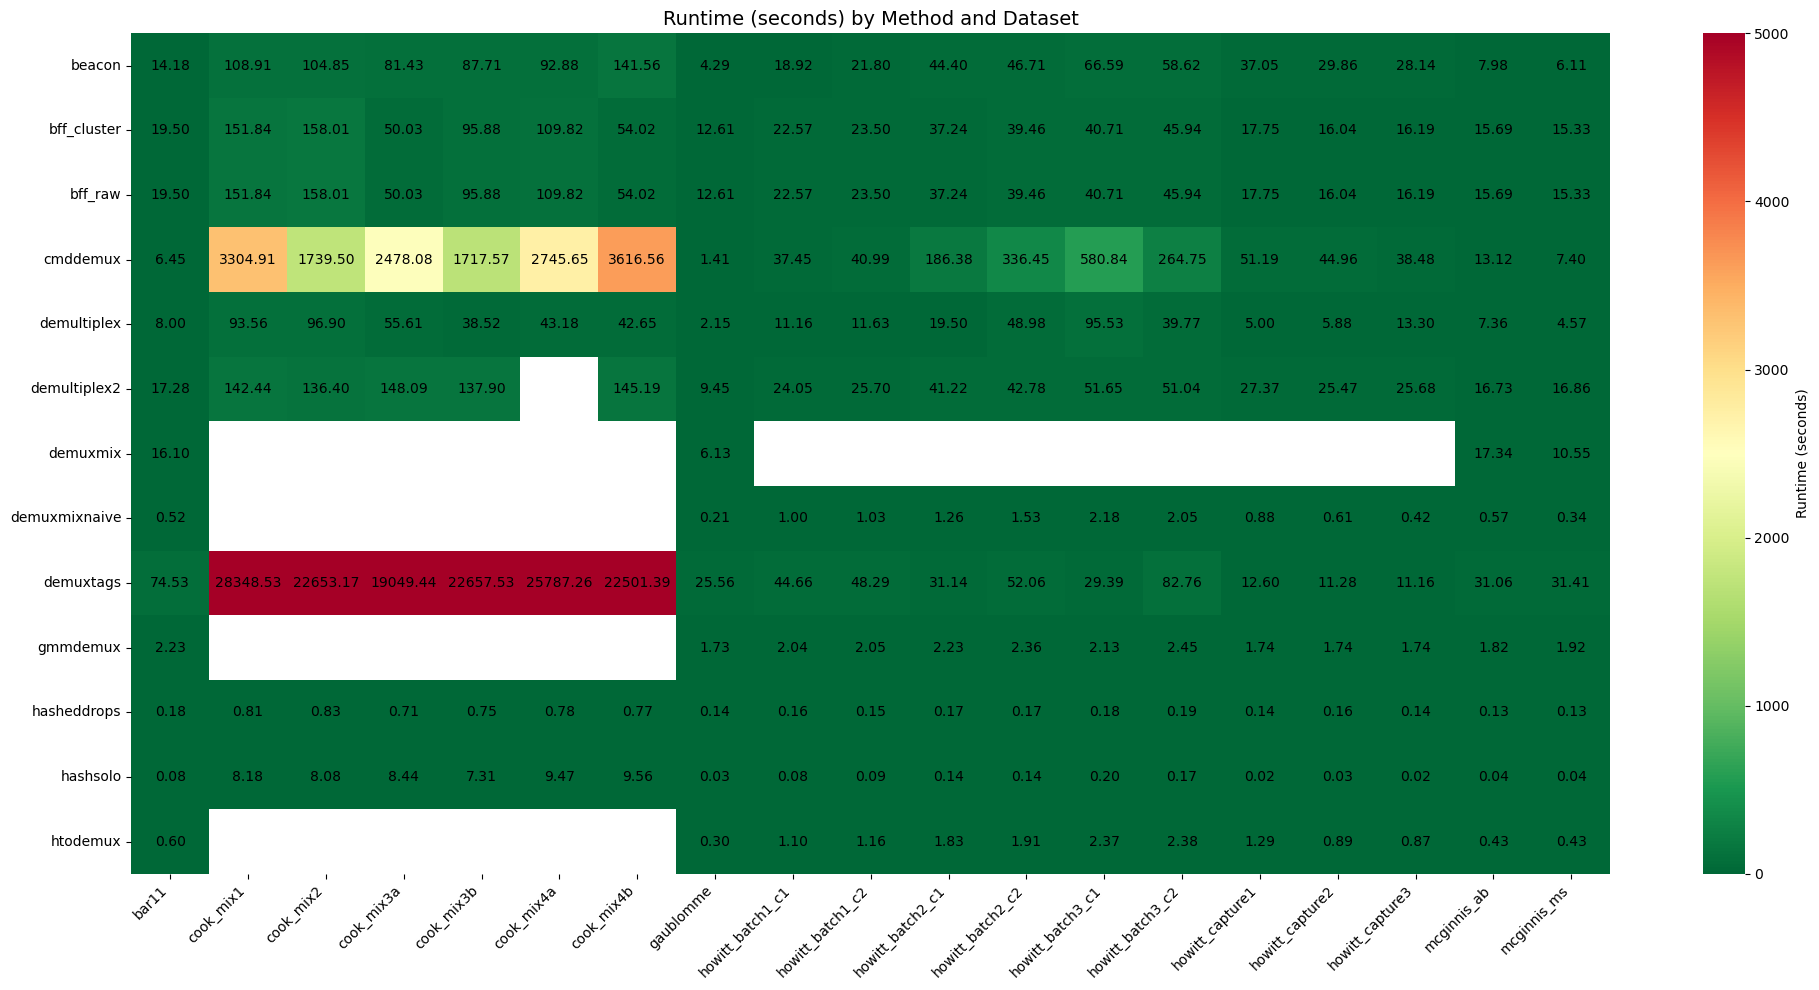

In [279]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(pivot, annot=annot_matrix, fmt='', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Runtime (seconds)'},
            vmin=0, vmax=5000,
            annot_kws={'color': 'black'})
ax.set_title('Runtime (seconds) by Method and Dataset', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

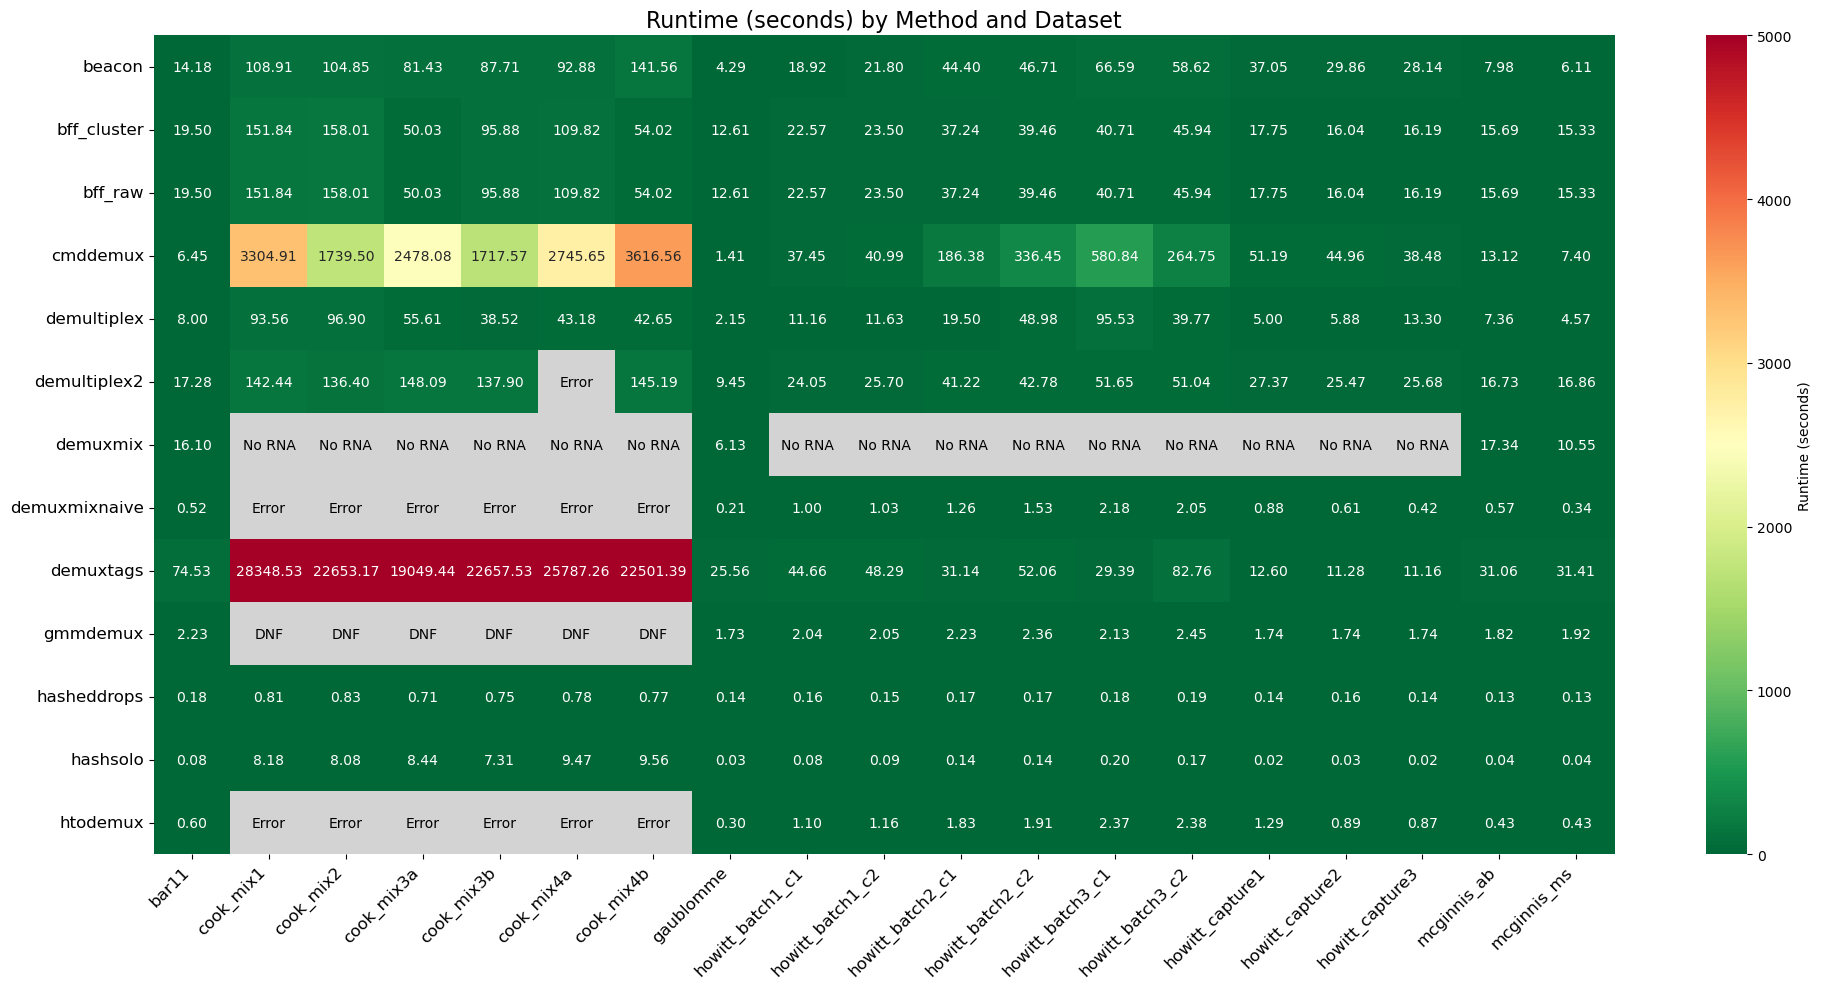

In [280]:
# create a copy with NaN filled for coloring
pivot_filled = pivot.copy()

# create mask for NaN cells
nan_mask = pivot.isna()

# fill NaN with 0 for the colormap but we'll overlay grey
pivot_filled = pivot.fillna(0)

fig, ax = plt.subplots(figsize=(20, 10))

# plot the heatmap
sns.heatmap(pivot_filled, annot=annot_matrix, fmt='', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Runtime (seconds)'},
            vmin=0, vmax=5000, mask=nan_mask,
            annot_kws={'size': 10})

# overlay grey for NaN cells
sns.heatmap(pivot_filled, mask=~nan_mask, cmap=['lightgrey'],
            ax=ax, cbar=False, vmin=0, vmax=1,
            annot=annot_matrix, fmt='',
            annot_kws={'color': 'black', 'size': 10})

ax.set_title('Runtime (seconds) by Method and Dataset', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('')
plt.yticks(fontsize=12)
plt.xticks(rotation=45, ha='right',fontsize=12)
plt.tight_layout()
plt.savefig('analysis/time_analysis/runtime_heatmap.pdf')
plt.show()

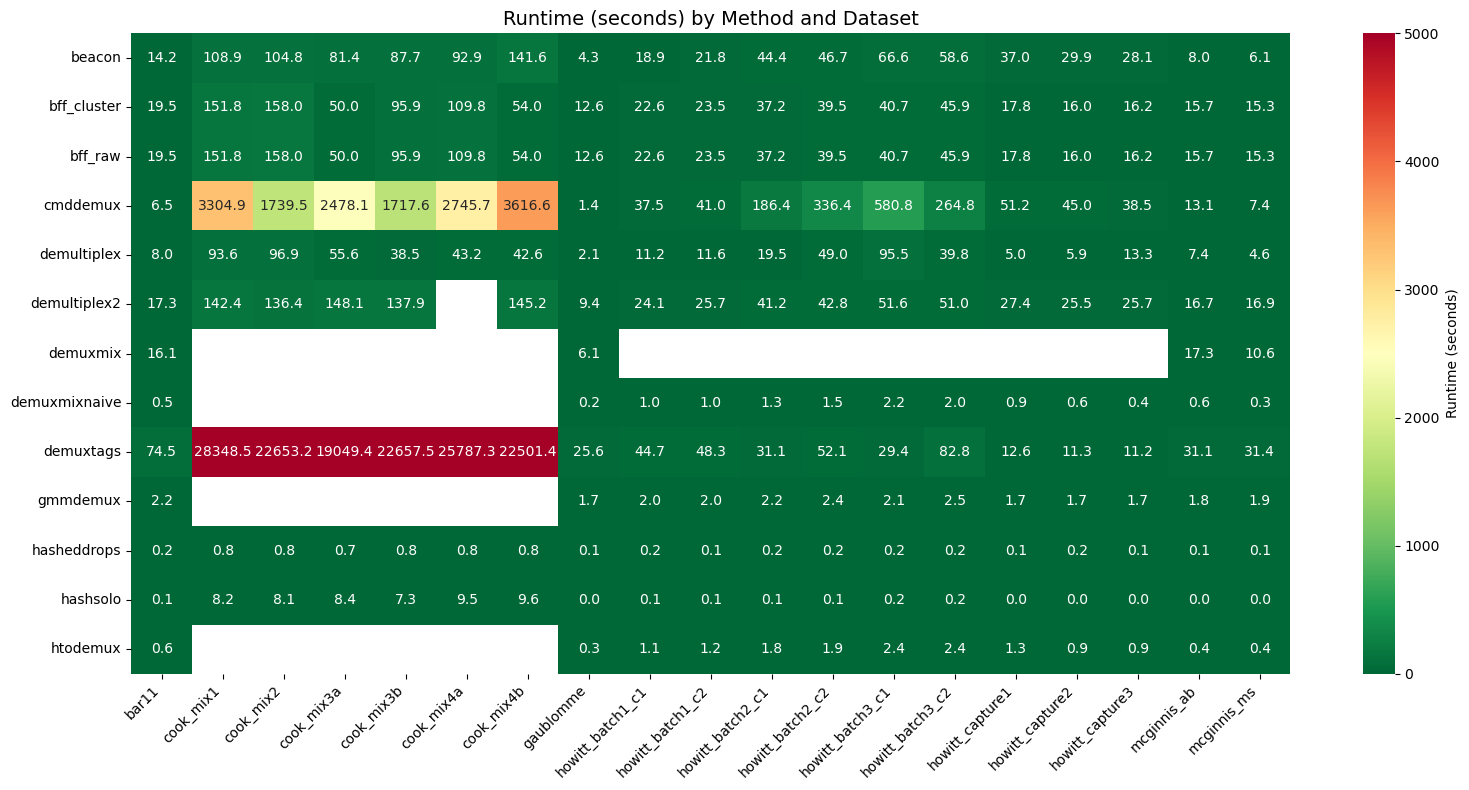

In [281]:
#heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Runtime (seconds)'}, vmin = 0, vmax = 5000)
ax.set_title('Runtime (seconds) by Method and Dataset', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('analysis/figures/runtime_heatmap.pdf')
plt.show()

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66666/1971470070.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([method_labels.get(m, m) for m in method_stats['method']],


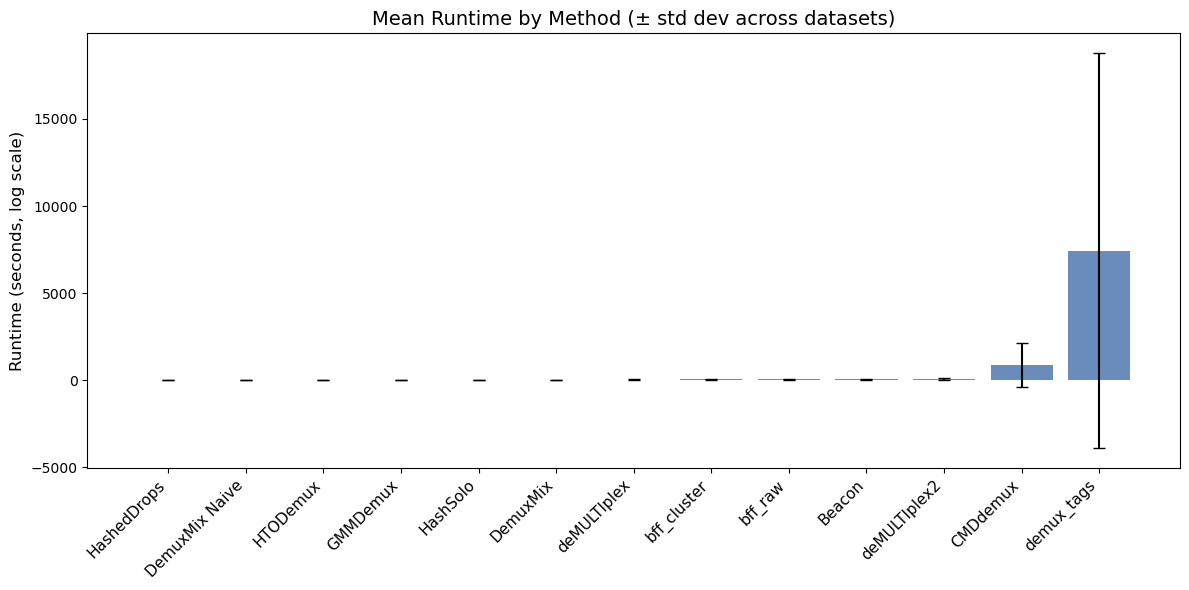

In [282]:
method_labels = {
    'demultiplex': 'deMULTIplex',
    'demultiplex2': 'deMULTIplex2',
    'htodemux': 'HTODemux',
    'hashsolo': 'HashSolo',
    'hasheddrops': 'HashedDrops',
    'bffraw': 'BFF_Raw',
    'bffcluster': 'BFF_Cluster',
    'gmmdemux': 'GMMDemux',
    'demuxmix': 'DemuxMix',
    'demuxmixnaive': 'DemuxMix Naive',
    'demuxem': 'DemuxEM',
    'beacon': 'Beacon',
    'demuxtags': 'demux_tags',
    'cmddemux': 'CMDdemux'
}

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(method_stats))
ax.bar(x, method_stats['mean'], color='#446fac', alpha=0.8)
ax.errorbar(x, method_stats['mean'], yerr=method_stats['std'],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_xticklabels([method_labels.get(m, m) for m in method_stats['method']],
                   rotation=45, ha='right', fontsize=11)
ax.set_xticks(x)
ax.set_ylabel('Runtime (seconds)', fontsize=12)
#ax.set_yscale('log')
ax.set_ylabel('Runtime (seconds, log scale)', fontsize=12)
ax.set_title('Mean Runtime by Method (± std dev across datasets)', fontsize=14)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('analysis/figures/runtime_mean_std.pdf')
plt.show()

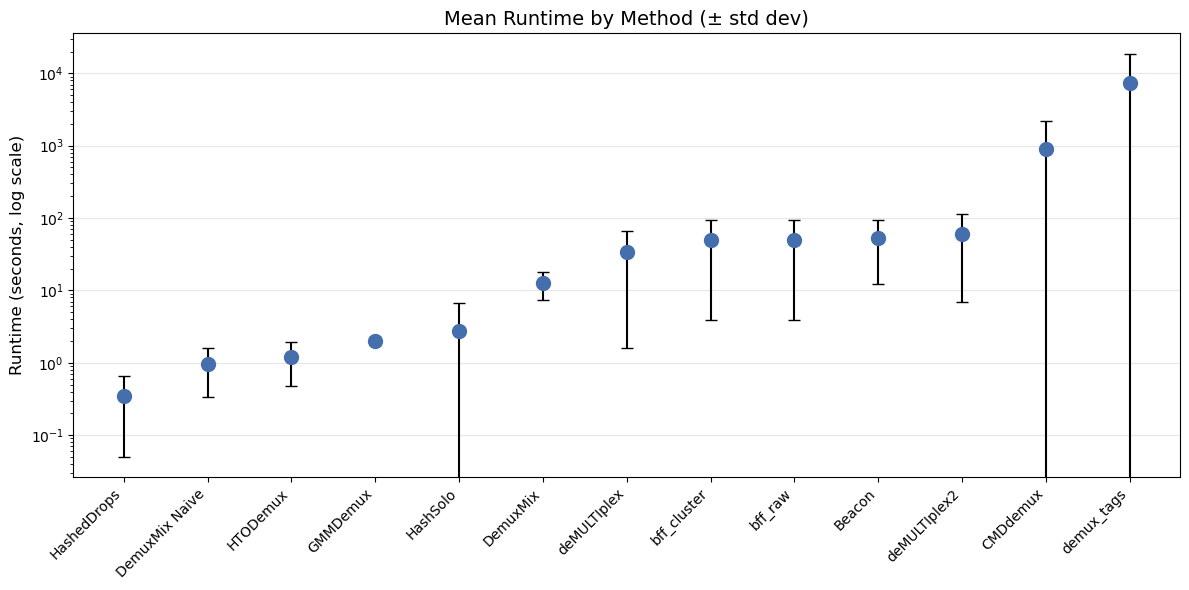

In [283]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(range(len(method_stats)), method_stats['mean'], 
           s=100, color='#446fac', zorder=3)
ax.errorbar(range(len(method_stats)), method_stats['mean'], 
            yerr=method_stats['std'], fmt='none', color='black', capsize=4)
ax.set_yscale('log')
ax.set_xticks(range(len(method_stats)))
ax.set_xticklabels([method_labels.get(m, m) for m in method_stats['method']],
                   rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Runtime (seconds, log scale)', fontsize=12)
ax.set_title('Mean Runtime by Method (± std dev)', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

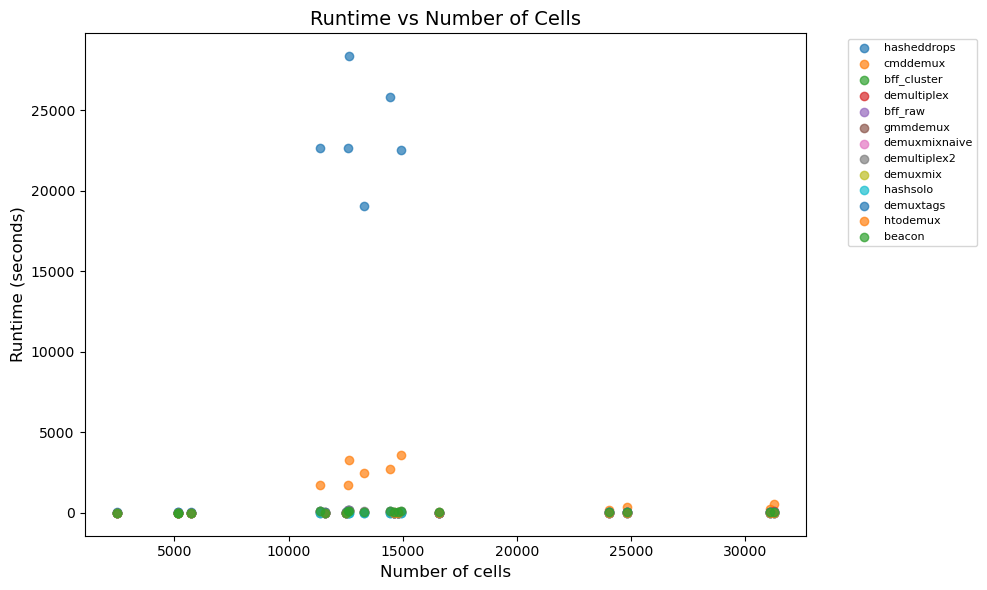

In [284]:
#scatterplot (runtime vs n_cells)

# load cell counts from summary csvs
cell_counts = []
for method in methods:
    files = glob.glob(f'results/{method}/*/summary.csv')
    for f in files:
        dataset_id = f.split('/')[2]
        df = pd.read_csv(f)
        total = df[df['classification'] == 'total']['n'].values
        if len(total) > 0:
            cell_counts.append({'dataset': dataset_id, 'n_cells': total[0]})

cell_counts_df = pd.DataFrame(cell_counts).drop_duplicates('dataset')

# merge with runtimes
scatter_df = runtimes_df.merge(cell_counts_df, on='dataset')

fig, ax = plt.subplots(figsize=(10, 6))
for method in scatter_df['method'].unique():
    subset = scatter_df[scatter_df['method'] == method]
    ax.scatter(subset['n_cells'], subset['runtime_seconds'],
               label=method, alpha=0.7)

ax.set_xlabel('Number of cells', fontsize=12)
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Runtime vs Number of Cells', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('analysis/figures/runtime_vs_ncells.pdf')
plt.show()